Load trained models

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow.lightgbm
import numpy as np
import polars as pl

import src.production_models as production_models
import src.tracking as tracking

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
BLUE, ORANGE = "#2a78d6", "#eb6834"

tracking.configure_mlflow()
models_dir = "data/processed/models"
manifest = json.load(open(f"{models_dir}/_manifest.json"))

production = production_models.load_production_models()

ranker = mlflow.lightgbm.load_model(f"runs:/{production.ranker_run_id}/ranker")
classifier = mlflow.lightgbm.load_model(f"runs:/{production.classifier_run_id}/classifier")

manifest["ranker"]["best_iteration"], manifest["classifier"]["best_iteration"]

(207, 279)

Training score distributions

In [2]:
# distributions: pipelines/report_score_distributions.py
distributions = json.load(open(f"{models_dir}/_score_distributions.json"))
assert distributions["ranker_run_id"] == production.ranker_run_id
assert distributions["classifier_run_id"] == production.classifier_run_id

distributions["rows"], distributions["positives"], distributions["positive_rate"]

(1002471, 91187, 0.09096223232392757)

Ranker score distribution

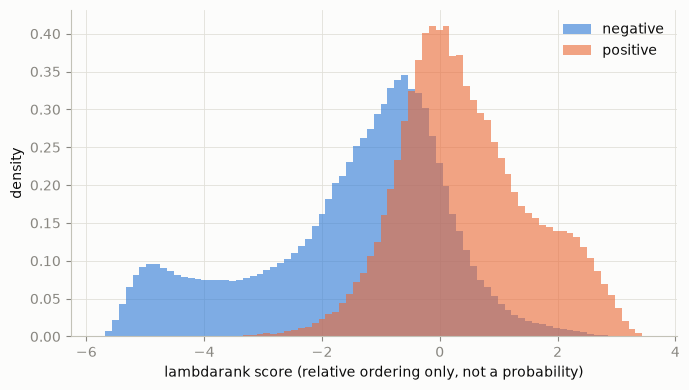

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
dist = distributions["ranker"]
edges = np.array(dist["bin_edges"])
for key, color, label in (("negative_counts", BLUE, "negative"), ("positive_counts", ORANGE, "positive")):
    counts = np.array(dist[key])
    ax.stairs(counts / (counts.sum() * np.diff(edges)), edges, fill=True, color=color, alpha=0.6, label=label)
ax.set_xlabel("lambdarank score (relative ordering only, not a probability)")
ax.set_ylabel("density")
ax.legend(frameon=False)
fig.tight_layout()

Classifier probability distribution

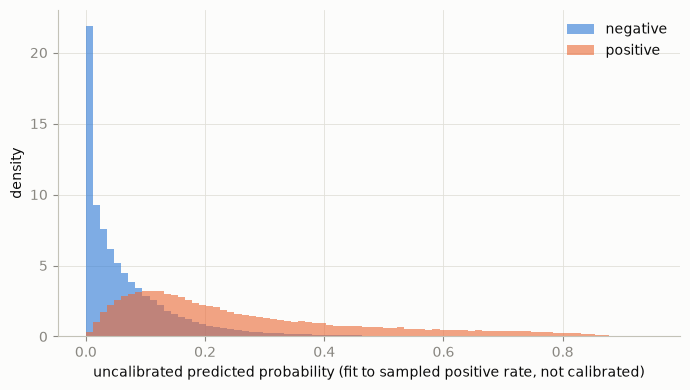

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
dist = distributions["classifier"]
edges = np.array(dist["bin_edges"])
for key, color, label in (("negative_counts", BLUE, "negative"), ("positive_counts", ORANGE, "positive")):
    counts = np.array(dist[key])
    ax.stairs(counts / (counts.sum() * np.diff(edges)), edges, fill=True, color=color, alpha=0.6, label=label)
ax.set_xlabel("uncalibrated predicted probability (fit to sampled positive rate, not calibrated)")
ax.set_ylabel("density")
ax.legend(frameon=False)
fig.tight_layout()

Top 15 features by gain, ranker

In [5]:
import pandas as pd


def top_gain(model, n=15):
    gain = model.booster_.feature_importance(importance_type="gain")
    names = model.booster_.feature_name()
    df = pd.DataFrame({"feature": names, "gain": gain})
    df["gain_share"] = df["gain"] / df["gain"].sum()
    return df.sort_values("gain", ascending=False).head(n).reset_index(drop=True)


ranker_top_gain = top_gain(ranker)
ranker_top_gain

,feature,gain,gain_share
0,purchase_count_1w,336016.258135,0.250821
1,days_since_last_purchase_this_article,239123.689959,0.178495
2,department_name,142791.391596,0.106587
3,rank_repurchase,58776.861029,0.043874
4,prior_purchase_count_same_product_code,56930.614509,0.042496
5,days_since_last_purchase,48258.823223,0.036023
6,prior_purchase_count_same_department,45446.340909,0.033924
7,product_type_name,43649.766921,0.032583
8,best_rank,43259.248508,0.032291
9,days_since_last_sale,39578.385670,0.029544


Top 15 features by gain, classifier

In [6]:
classifier_top_gain = top_gain(classifier)
classifier_top_gain

,feature,gain,gain_share
0,purchase_count_1w,442159.258698,0.272691
1,days_since_last_purchase_this_article,319291.613435,0.196915
2,department_name,148963.517130,0.091870
3,rank_repurchase,73416.282027,0.045278
4,prior_purchase_count_same_product_code,72592.014251,0.044769
5,days_since_last_sale,65280.966481,0.040260
6,days_since_last_purchase,55503.138381,0.034230
7,best_rank,49339.930000,0.030429
8,prior_purchase_count_same_department,40055.709733,0.024703
9,product_type_name,38669.811687,0.023849


Load calibration artifacts

In [7]:
import src.calibrate as calibrate

calibration_manifest = json.load(open("data/processed/calibration/_calibration_manifest.json"))
calibrator = calibrate.load_calibrator(Path("data/processed/models/calibrator.joblib"))
reliability = pl.DataFrame(calibration_manifest["reliability_table"])

reliability

bin,n,predicted_mean,observed_rate
i64,i64,f64,f64
0,2107610,0.0,0.0
1,2107610,0.000002,9.4894e-7
2,2107610,0.000009,0.000014
3,2107610,0.000049,0.000046
4,2107610,0.000106,0.000097
5,2107610,0.000145,0.000126
6,2107610,0.000156,0.000147
7,2107610,0.000209,0.00022
8,2107610,0.000287,0.000264


Brier scores

In [8]:
pl.DataFrame(
    {
        "metric": [
            "fit_rows", "eval_rows", "eval_base_rate",
            "raw_brier", "calibrated_brier", "constant_brier",
            "raw_brier_skill_score", "calibrated_brier_skill_score",
        ],
        "value": [
            float(calibration_manifest["fit_rows"]), float(calibration_manifest["eval_rows"]), calibration_manifest["eval_base_rate"],
            calibration_manifest["raw_brier"], calibration_manifest["calibrated_brier"], calibration_manifest["constant_brier"],
            calibration_manifest["raw_brier_skill_score"], calibration_manifest["calibrated_brier_skill_score"],
        ],
    }
)

metric,value
str,f64
"""fit_rows""",2.105221e7
"""eval_rows""",2.10761e7
"""eval_base_rate""",0.000198
"""raw_brier""",0.011997
"""calibrated_brier""",0.000198
"""constant_brier""",0.000198
"""raw_brier_skill_score""",-59.546852
"""calibrated_brier_skill_score""",0.002041


Calibration curve

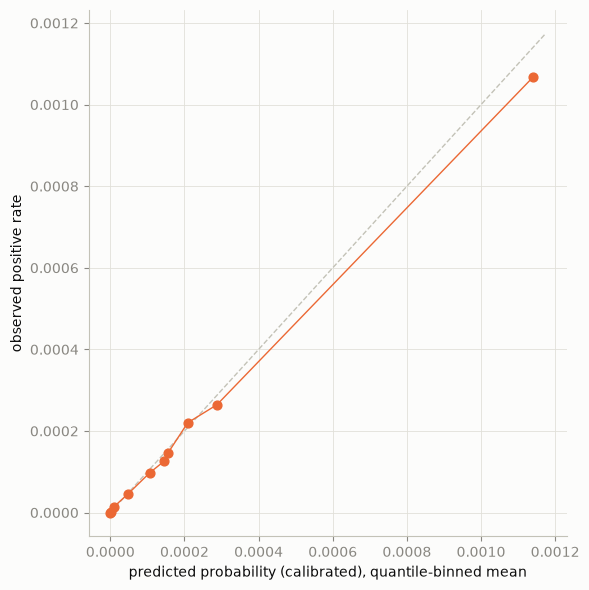

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
lim = reliability["observed_rate"].max() * 1.1
ax.plot([0, lim], [0, lim], color="#c3c2b7", linewidth=1, linestyle="--")
ax.scatter(reliability["predicted_mean"], reliability["observed_rate"], color=ORANGE, s=40, zorder=3)
ax.plot(reliability["predicted_mean"], reliability["observed_rate"], color=ORANGE, linewidth=1, zorder=2)
ax.set_xlabel("predicted probability (calibrated), quantile-binned mean")
ax.set_ylabel("observed positive rate")
fig.tight_layout()

MAP@12

In [10]:
map12_manifest = json.load(open("data/processed/evaluation/_map12_manifest.json"))

orderings = pl.DataFrame(
    [
        {"ordering": name, **stats}
        for name, stats in map12_manifest["orderings"].items()
    ]
)
orderings

ordering,map_at_12,customers_scored
str,f64,i64
"""ranker""",0.035295,68984
"""recent_popularity""",0.008748,68984
"""candidate_pool_order""",0.013459,68984
"""oracle""",0.120309,68984


MAP@12 by ordering

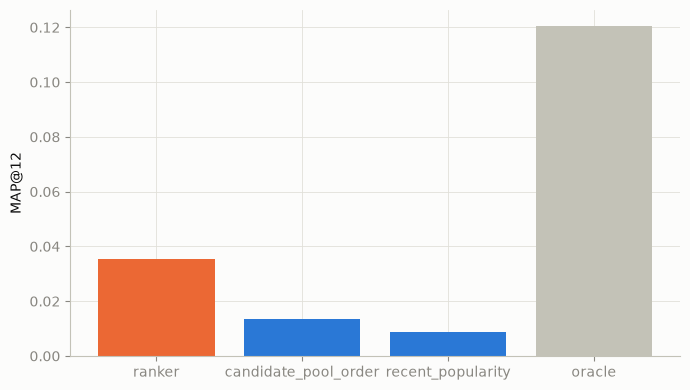

In [11]:
order = ["ranker", "candidate_pool_order", "recent_popularity", "oracle"]
values = [map12_manifest["orderings"][o]["map_at_12"] for o in order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(order, values, color=[ORANGE, BLUE, BLUE, "#c3c2b7"])
ax.set_ylabel("MAP@12")
fig.tight_layout()

Ranker MAP@12 by recency bucket

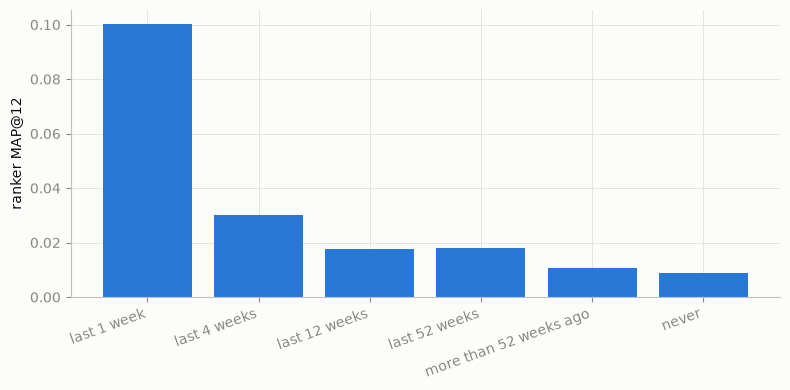

In [12]:
import src.evaluate as evaluate

bucket_order = evaluate.RECENCY_BUCKET_LABELS + ["never"]
bucket_df = pl.DataFrame(map12_manifest["ranker_map_at_12_by_recency_bucket"])
bucket_df = bucket_df.with_columns(
    pl.col("recency_bucket").cast(pl.Enum(bucket_order))
).sort("recency_bucket")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bucket_df["recency_bucket"], bucket_df["map_at_12"], color=BLUE)
ax.set_ylabel("ranker MAP@12")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()